## Import and Load data

In [ ]:
from qualibrate import QualibrationNode
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import json
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path


2026-03-21 16:04:04,010 - qm - INFO     - Starting session: 8a5bd949-2989-44e8-a04b-9b9593a85da5


In [ ]:
id_qpt, id_gst, id_ell = 946, 781, 947
gst_depth = 4
node = QualibrationNode('robustness_to_fidelity')
data_path = Path("data/gst_qpt_ellipsoid").resolve()
da_gst = node.load_from_id(id_gst, base_path=data_path).results['ds'].sel(depth=gst_depth).sel(model_type='CPTP').robustness
da_qpt = node.load_from_id(id_qpt, base_path=data_path).results['ds'].sel(model_type='mitigated').robustness
da_ell = node.load_from_id(id_ell, base_path=data_path).results['ds'].sel(model_type='MLE data').robustness
da_fid = node.load_from_id(id_qpt, base_path=data_path).results['ds'].sel(model_type='mitigated').fidelity

da_gst = da_gst.assign_coords(fidelity=da_fid)
da_qpt = da_qpt.assign_coords(fidelity=da_fid)
da_ell = da_ell.assign_coords(fidelity=da_fid)

2026-03-21 16:04:05,417 - qualibrate - INFO - Creating node robustness_to_fidelity


## qpt vs ellipsoid

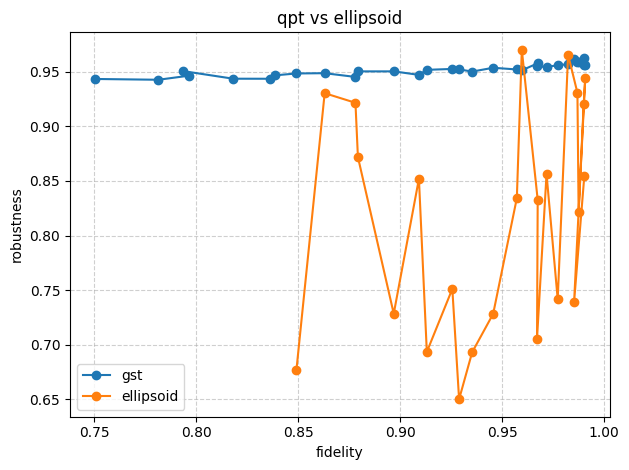

In [ ]:
da_qpt.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='qpt'
)
da_ell.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='ellipsoid'
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.title('qpt vs ellipsoid')
plt.show()


## gst vs ellipsoid

In [ ]:
da_gst.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='gst'
)
da_ell.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='ellipsoid'
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.title('gst vs ellipsoid')
plt.show()

## gst, qpt ellipsoid

In [ ]:
da_gst.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='gst'
)
da_qpt.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='qpt'
)
da_ell.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='ellipsoid'
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.title('gst vs ellipsoid')
plt.show()